# 04 · Student-t — fatter tails for the walk

## Executive summary (read this first)

**The problem.** The walk draws its random numbers from a normal bell curve. Notebooks 02–03 showed its tails
are too thin: on test, the answer falls inside the 90 % band only 83–87 % of the time in F1–F3, and the PIT
histograms pile up at both ends. Real markets have more extreme moves than a bell curve with the same sd.

**The change — one line.** Each leg's standard normal `z` becomes a **Student-t** number with the same
variance:

```
z_t = z × √((ν − 2) / W),      W ~ chi-square(ν)
```

- **Variance stays 1**, so `window` and `widen` mean exactly what they meant before.
- **The Cholesky correlation stays**: every asset of a draw shares the same `W`, so the assets have their extreme
  days together (a *multivariate* t).
- **ν (degrees of freedom)** is the new hyperparameter: small ν = fat tails (ν = 3 is very fat), large ν ≈ the
  normal. Since each leg is one draw, the **h-day move itself** is t-distributed.

**How it is chosen and judged** — the same protocol as notebook 02, against the current model (the normal walk
with the one-per-family settings of notebook 02):

1. **train** — for each family, try ν ∈ {3, 4, 5, 6, 8, 12, 20, normal} × `widen` ∈ {0.8 … 1.2} at the family's
   window; keep the best pair;
2. **validation** — keep the t version for a family only if it beats the normal model there;
3. **test** — opened once, final model against the normal model.

Each card's own score from its `card.toml` (raw, no M0), its three parts, and the share of answers inside the
50 %, 90 % and **98 %** bands (the tail score looks at the 1 % and 99 % points). The printed lines in §6–§7 are
the result.

## 0 — Setup, data and the current model

In [1]:
import json, multiprocessing as mp, pathlib, subprocess, sys, tempfile, time, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, DATA, UNITS = HERE.parent, HERE / "data", HERE.parent / "units"
if str(REPO) not in sys.path: sys.path.insert(0, str(REPO))

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 150)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
FAM = {"T2-F1": "#2a78d6", "T2-F2": "#eb6834", "T2-F3": "#1baf7a", "T2-F4": "#4a3aa7"}
NORMAL_C, T_C = "#8a8983", "#eb6834"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})

TARGETS = pd.read_parquet(DATA / "targets.parquet")
STEPS = pd.read_parquet(DATA / "steps.parquet")
CARDS = {u: tomllib.loads((UNITS / u / "card.toml").read_text()) for u in sorted(TARGETS.unit.unique())}
FAMILY = {u: CARDS[u]["metadata"]["category"] for u in CARDS}
WORKERS = max(1, (mp.cpu_count() or 2) - 2)
geo = lambda r: float(np.exp(np.log(np.asarray(r, float)).mean()))

def parse(setting):                                        # "130 / 1.1" -> {"window": 130, "widen": 1.1}
    w, wd = (x.strip() for x in str(setting).split("/"))
    return {"window": int(w), "widen": float(wd)}

per_family = pd.read_csv(DATA / "walk_settings.csv", index_col=0)["one per family"]
NORMAL = {u: {**parse(per_family[u]), "nu": None} for u in CARDS}          # the current model: normal walk
print("current model (normal walk, one setting per family, from notebook 02):")
pd.DataFrame({f: NORMAL[next(u for u in CARDS if FAMILY[u] == f)] for f in sorted(FAM)}).T

current model (normal walk, one setting per family, from notebook 02):


,window,widen,nu
T2-F1,42.0,1.1,NaN
T2-F2,130.0,1.0,NaN
T2-F3,130.0,1.0,NaN
T2-F4,260.0,1.1,NaN


## 1 — The model: the walk with a Student-t option

`walk_forecast(..., nu=None)` is exactly the normal walk of notebooks 02–03. With a number `nu`, each leg's
correlated normals are multiplied by `√((ν − 2) / W)`, one `W ~ chi-square(ν)` per draw and leg, shared by all
assets. `W` comes from a **second** random stream, so the normal part of every draw is the same number as in
the normal walk: any difference between the two models comes from the tails, not from luck.

In [2]:
MIN_CHANGES = 10

def walk_forecast(steps, origin, anchor, ksteps, horizons, window=260, widen=1.0, nu=None, n_draws=1000, seed=0):
    """Cumulative random walk with Cholesky; normal (nu=None) or multivariate Student-t shocks with unit variance."""
    i = steps.index.searchsorted(pd.Timestamp(origin), side="right")
    past = steps.to_numpy()[max(0, i - window): i]
    if len(past) < MIN_CHANGES:
        raise ValueError(f"only {len(past)} steps before {origin} (window {window})")
    n_a = past.shape[1]
    D = np.ascontiguousarray(past.T)
    sd = D.std(axis=1) * widen
    with np.errstate(invalid="ignore", divide="ignore"):
        corr = np.nan_to_num(np.atleast_2d(np.corrcoef(D)), nan=0.0)
    np.fill_diagonal(corr, 1.0)
    w, v = np.linalg.eigh(corr)
    corr = v @ np.diag(np.clip(w, 1e-8, None)) @ v.T
    L = np.linalg.cholesky(corr)
    rng = np.random.default_rng(seed)
    rng_t = np.random.default_rng([seed, 7])                                   # the tail stream (t only)
    out = np.empty((n_draws, n_a, len(horizons)))
    path, prev = np.zeros((n_draws, n_a)), np.zeros(n_a)
    for hi in np.argsort(horizons):
        z = rng.standard_normal((n_draws, n_a)) @ L.T                          # correlated standard normals
        rng.standard_normal((n_draws, n_a))                                    # production's skew draw (unused)
        if nu is not None:
            z = z * np.sqrt((nu - 2.0) / rng_t.chisquare(nu, size=(n_draws, 1)))   # same W for every asset
        kk = np.asarray(ksteps, float)[:, hi]
        path = path + z * sd * np.sqrt(np.maximum(kk - prev, 0))
        prev = kk
        out[:, :, hi] = np.asarray(anchor, float) + path
    return out

from qfbench2_track_forecasting import scoring as S

def card_score(card, samples, y):
    """The card's own score (raw), its parts, and the share of cells inside the 50 / 90 / 98 % bands."""
    p = card.get("scoring", {}).get("params", {})
    w = p.get("weights", {"marginal": 0.5, "joint": 0.3, "tail": 0.2})
    w = (float(w["marginal"]), float(w["joint"]), float(w["tail"]))
    if samples.shape[1] == 1:
        live = w[0] + w[2]; w = (w[0] / live, 0.0, w[2] / live)
    out = S._composite(samples, y, weights=w, tail_levels=tuple(p.get("tail_levels", (0.01, 0.05, 0.95, 0.99))),
                       joint=S.card_joint_statistic(card), tail_metric=str(p.get("tail_metric", S.DEFAULT_TAIL_METRIC)),
                       ref_scale=None)
    q = np.quantile(samples, [0.01, 0.05, 0.25, 0.75, 0.95, 0.99], axis=0)
    inside = lambda lo, hi: float(np.mean((y >= q[lo]) & (y <= q[hi])))
    return {**out, "cov50": inside(2, 3), "cov90": inside(1, 4), "cov98": inside(0, 5)}

def card_inputs(u):
    card = CARDS[u]; t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    steps = STEPS[STEPS.unit == u].pivot(index="date", columns="asset", values="step")[assets].sort_index()
    tt = TARGETS[TARGETS.unit == u].set_index(["origin_date", "asset", "horizon"]).sort_index()
    return card, assets, horizons, steps, tt

def at_origin(tt, origin, assets, horizons):
    r = tt.loc[origin]
    anchor = np.array([r.loc[(a, horizons[0]), "anchor"] for a in assets])
    ksteps = np.array([[r.loc[(a, h), "steps"] for h in horizons] for a in assets])
    y = np.array([r.loc[(a, h), "target"] for a in assets for h in horizons])
    return anchor, ksteps, y

**What the t does to the shape.** 200,000 unit-variance draws each. A smaller ν keeps the same sd but puts
more mass in the centre **and** in the far tails: the 5 % / 95 % points move *in*, the 1 % / 99 % points and
beyond move *out*.

,sd,95% point,99% point,99.9% point,share beyond 3 sd
shape,,,,,
normal,1.001,1.645,2.331,3.102,0.003
"t, ν=20",1.002,1.636,2.408,3.395,0.005
"t, ν=8",1.001,1.604,2.503,3.984,0.009
"t, ν=5",1.004,1.560,2.621,4.620,0.012
"t, ν=3",0.992,1.363,2.639,5.843,0.014


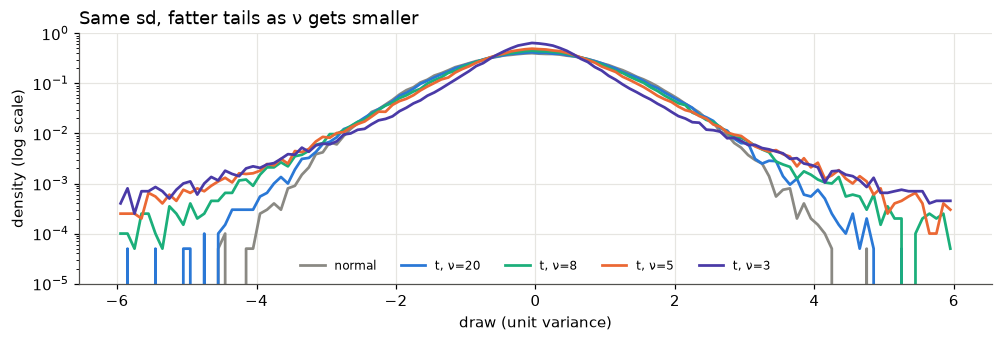

In [3]:
rng_demo = np.random.default_rng(0)
zn = rng_demo.standard_normal(200_000)
rows, shapes = [], {"normal": zn}
for nu in (20, 8, 5, 3):
    shapes[f"t, ν={nu}"] = zn * np.sqrt((nu - 2) / np.random.default_rng(nu).chisquare(nu, 200_000))
for name, v in shapes.items():
    q = np.quantile(v, [0.95, 0.99, 0.999])
    rows.append({"shape": name, "sd": v.std(), "95% point": q[0], "99% point": q[1], "99.9% point": q[2],
                 "share beyond 3 sd": np.mean(np.abs(v) > 3)})
display(pd.DataFrame(rows).set_index("shape").round(3))

fig, ax = plt.subplots(figsize=(9, 3), layout="constrained")
bins = np.linspace(-6, 6, 121)
for (name, v), col in zip(shapes.items(), ["#8a8983", "#2a78d6", "#1baf7a", "#eb6834", "#4a3aa7"]):
    h, e = np.histogram(v, bins=bins, density=True)
    ax.plot((e[1:] + e[:-1]) / 2, h, color=col, lw=1.8, label=name)
ax.set_yscale("log"); ax.set_ylim(1e-5, 1); ax.set_xlabel("draw (unit variance)"); ax.set_ylabel("density (log scale)")
ax.legend(ncols=5, fontsize=8); ax.set_title("Same sd, fatter tails as ν gets smaller"); plt.show()

## 2 — Checks

1. With `nu=None` and production's settings (260 / 1.0) the draws equal production's walk exactly.
2. With a t setting, `card_score` equals the official scorer's number.
3. The t draws keep the correlation between assets and the sd of each cell (up to sampling noise).

In [4]:
import forecast_agent as fa, forecast_models as fm
u = "t2-F3-boj-ust-channel-2023"
card, assets, horizons, steps, tt = card_inputs(u); t = card["targets"]
o = np.sort(tt[tt.split == "test"].index.get_level_values(0).unique())[100]
anchor, ksteps, y = at_origin(tt, o, assets, horizons)
mine = walk_forecast(steps, o, anchor, ksteps, horizons, window=260, widen=1.0, nu=None, seed=3)
req = fm._Request(fa._read_panels(UNITS / u), assets, horizons, str(pd.Timestamp(o).date()), {a: {} for a in assets},
                  1000, 3, t["target_type"], None)   # family None: production's plain walk (260 / 1.0 / normal)
diff = float(np.abs(mine - fm._cumulative_walk_model(req)).max())
print("1. normal walk vs production, max |difference|:", diff); assert diff == 0

d3 = walk_forecast(steps, o, anchor, ksteps, horizons, window=130, widen=1.0, nu=4)
with tempfile.TemporaryDirectory() as tmp:
    out_dir, real = pathlib.Path(tmp) / "out", pathlib.Path(tmp) / "realized.parquet"; out_dir.mkdir()
    pd.DataFrame([{"draw": np.int32(d), "asset": a, "horizon": np.int32(h), "value": float(d3[d, ai, hi])}
                  for d in range(len(d3)) for ai, a in enumerate(assets) for hi, h in enumerate(horizons)]).to_parquet(out_dir / "forecast.parquet", index=False)
    (out_dir / "forecast_meta.json").write_text(json.dumps({"unit_id": card["task"]["id"], "asof": card["provenance"]["data_cutoff"],
        "representation": "samples", "asset_ids": assets, "horizons": horizons, "n_draws": len(d3), "target": t["target_type"]}))
    (out_dir / "forecast_rationale.md").write_text("# check\n")
    pd.DataFrame([{"asset": a, "horizon": h, "value": float(v)} for (a, h), v in zip([(a, h) for a in assets for h in horizons], y)]).to_parquet(real, index=False)
    r = subprocess.run([sys.executable, str(REPO / "scoring" / "scoring.py"), "score", "--card", str(UNITS / u / "card.toml"),
                        "--forecast", str(out_dir / "forecast.parquet"), "--realized", str(real)], capture_output=True, text=True, cwd=REPO)
official, mine_s = json.loads(r.stdout)["composite_score"], card_score(card, d3.reshape(len(d3), -1), y)["composite"]
print(f"2. t-walk score {mine_s:.10f}  official scorer {official:.10f}  equal: {np.isclose(mine_s, official, rtol=0, atol=1e-12)}")
assert np.isclose(mine_s, official, rtol=0, atol=1e-12)

big_n = walk_forecast(steps, o, anchor, ksteps, horizons, window=130, nu=None, n_draws=200_000, seed=1)
big_t = walk_forecast(steps, o, anchor, ksteps, horizons, window=130, nu=4, n_draws=200_000, seed=1)
print("3. 21-day cells, normal vs t(4):  sd UST_10Y", np.round([big_n[:, 0, 0].std(), big_t[:, 0, 0].std()], 4),
      "| sd JPY", np.round([big_n[:, 1, 0].std(), big_t[:, 1, 0].std()], 3),
      "| corr UST_10Y~JPY", np.round([np.corrcoef(big_n[:, 0, 0], big_n[:, 1, 0])[0, 1], np.corrcoef(big_t[:, 0, 0], big_t[:, 1, 0])[0, 1]], 3))

1. normal walk vs production, max |difference|: 0.0


2. t-walk score 3.1387361654  official scorer 3.1387361654  equal: True
3. 21-day cells, normal vs t(4):  sd UST_10Y [0.1982 0.1968] | sd JPY [4.019 3.998] | corr UST_10Y~JPY [0.482 0.483]


## 3 — The runner

`score_card` scores a list of settings on one card's dates of one block, the same random numbers for every
setting at a date; cards run in parallel. (Same design as notebook 02.)

In [5]:
def key(s):
    return f'{int(s["window"])} / {float(s["widen"]):.1f} / ' + ("normal" if s["nu"] is None else f'ν={int(s["nu"])}')

def score_card(args):
    u, block, settings, stride, n_draws, keep_pit = args
    card, assets, horizons, steps, tt = card_inputs(u)
    sub = tt[tt.split == block]
    cells = [(a, h) for a in assets for h in horizons]
    rows, pits = [], []
    for j, o in enumerate(np.sort(sub.index.get_level_values(0).unique())[::stride]):
        anchor, ksteps, y = at_origin(sub, o, assets, horizons)
        try:
            draws = [walk_forecast(steps, o, anchor, ksteps, horizons, n_draws=n_draws, seed=j, **s).reshape(n_draws, -1)
                     for s in settings]
        except ValueError:
            continue
        for s, d in zip(settings, draws):
            rows.append({"unit": u, "family": FAMILY[u], "block": block, "origin": o, "setting": key(s), **card_score(card, d, y)})
            if keep_pit:
                pits += [{"unit": u, "family": FAMILY[u], "origin": o, "setting": key(s), "asset": a, "horizon": h, "pit": float(p)}
                         for (a, h), p in zip(cells, (d < y).mean(axis=0))]
    return rows, pits

def run(jobs):
    with mp.get_context("fork").Pool(WORKERS) as pool:
        out = pool.map(score_card, jobs, chunksize=1)
    return pd.DataFrame([r for rows, _ in out for r in rows]), pd.DataFrame([p for _, ps in out for p in ps])

## 4 — Tune ν and `widen` on train, per family

Each card at its family's window; every 21st train date, 500 draws. A pair's quality in a family = the
geometric mean, over the family's cards, of (pair's mean score ÷ the current normal model's mean score).

In [6]:
NUS, WIDENS = [3, 4, 5, 6, 8, 12, 20, None], [0.8, 0.9, 1.0, 1.1, 1.2]

def grid_for(u):
    w = NORMAL[u]["window"]
    g = [{"window": w, "widen": wd, "nu": nu} for nu in NUS for wd in WIDENS]
    return g + ([NORMAL[u]] if NORMAL[u] not in g else [])

t0 = time.time()
tr, _ = run([(u, "train", grid_for(u), 21, 500, False) for u in CARDS])
print(f"train: {tr.groupby('unit').origin.nunique().sum():,} dates x {len(grid_for(next(iter(CARDS))))} settings = {len(tr):,} forecasts, {time.time() - t0:.0f}s")

m = tr.groupby(["unit", "family", "setting"]).composite.mean().rename("score").reset_index()
base = {u: m[(m.unit == u) & (m.setting == key(NORMAL[u]))].score.iloc[0] for u in m.unit.unique()}
m["ratio"] = m.score / m.unit.map(base)
parts = m.setting.str.split(" / ", expand=True); m["widen"] = parts[1].astype(float); m["shape"] = parts[2]
grid = m.groupby(["family", "shape", "widen"]).ratio.apply(geo).unstack("widen")
order = [f"ν={n}" for n in NUS if n is not None] + ["normal"]
for f in sorted(FAM):
    print(f"\n{f}: train score ÷ current normal model (rows: shape, columns: widen)")
    display(grid.loc[f].reindex(order).round(3))

CHOSEN = {}
for f in sorted(FAM):
    g = m[m.family == f].groupby("setting").ratio.apply(geo)
    CHOSEN[f] = g.idxmin()
print("chosen on train (window / widen / shape):", CHOSEN)

train: 8,671 dates x 40 settings = 346,840 forecasts, 13s

T2-F1: train score ÷ current normal model (rows: shape, columns: widen)


widen,0.8,0.9,1.0,1.1,1.2
shape,,,,,
ν=3,1.100,1.069,1.044,1.026,1.012
ν=4,1.068,1.041,1.022,1.009,1.001
ν=5,1.057,1.032,1.015,1.003,0.998
ν=6,1.053,1.029,1.012,1.003,0.999
ν=8,1.048,1.025,1.010,1.001,0.998
ν=12,1.045,1.022,1.008,1.000,0.999
ν=20,1.042,1.020,1.007,1.000,0.999
normal,1.039,1.018,1.006,1.000,1.000



T2-F2: train score ÷ current normal model (rows: shape, columns: widen)


widen,0.8,0.9,1.0,1.1,1.2
shape,,,,,
ν=3,1.033,1.018,1.008,1.002,0.998
ν=4,1.017,1.006,0.999,0.997,0.998
ν=5,1.013,1.003,0.998,0.997,1.000
ν=6,1.012,1.002,0.998,0.998,1.002
ν=8,1.010,1.001,0.998,0.999,1.004
ν=12,1.009,1.001,0.999,1.001,1.007
ν=20,1.009,1.001,0.999,1.002,1.009
normal,1.009,1.001,1.000,1.004,1.012



T2-F3: train score ÷ current normal model (rows: shape, columns: widen)


widen,0.8,0.9,1.0,1.1,1.2
shape,,,,,
ν=3,1.101,1.064,1.037,1.017,1.004
ν=4,1.063,1.033,1.012,1.001,0.997
ν=5,1.051,1.023,1.006,0.998,0.998
ν=6,1.045,1.019,1.004,0.998,1.000
ν=8,1.039,1.015,1.002,0.998,1.002
ν=12,1.035,1.012,1.000,0.998,1.005
ν=20,1.032,1.010,1.000,0.999,1.007
normal,1.029,1.009,1.000,1.001,1.010



T2-F4: train score ÷ current normal model (rows: shape, columns: widen)


widen,0.8,0.9,1.0,1.1,1.2
shape,,,,,
ν=3,1.069,1.046,1.030,1.018,1.010
ν=4,1.044,1.025,1.011,1.004,1.000
ν=5,1.036,1.018,1.007,1.001,0.999
ν=6,1.032,1.015,1.005,1.000,1.000
ν=8,1.028,1.012,1.003,0.999,1.000
ν=12,1.026,1.011,1.002,1.000,1.002
ν=20,1.024,1.009,1.001,1.000,1.003
normal,1.022,1.008,1.001,1.000,1.004


chosen on train (window / widen / shape): {'T2-F1': '42 / 1.2 / ν=5', 'T2-F2': '130 / 1.1 / ν=4', 'T2-F3': '130 / 1.2 / ν=4', 'T2-F4': '260 / 1.2 / ν=5'}


## 5 — Validation: keep the t version for a family only if it beats the normal model there

The chosen t setting and the current normal model, on every card's validation dates (every 5th, 1,000 draws).

In [7]:
def setting_of(label):
    w, wd, shape = [x.strip() for x in label.split("/")]
    return {"window": int(w), "widen": float(wd), "nu": None if shape == "normal" else int(shape.split("=")[1])}

CANDIDATE = {u: setting_of(CHOSEN[FAMILY[u]]) for u in CARDS}

def compare(block, model_a, model_b, keep_pit=False):
    jobs = [(u, block, [model_a[u]] + ([model_b[u]] if model_b[u] != model_a[u] else []), 5, 1000, keep_pit) for u in CARDS]
    sc, pit = run(jobs)
    cm = sc.groupby(["unit", "setting"])[["composite", "marginal", "joint", "tail", "cov50", "cov90", "cov98"]].mean()
    rows = []
    for u in sorted(set(sc.unit)):
        a, b = cm.loc[(u, key(model_a[u]))], cm.loc[(u, key(model_b[u]))]
        rows.append({"unit": u, "family": FAMILY[u], "ratio": a.composite / b.composite,
                     **{f"{c}_ratio": (a[c] / b[c] if b[c] > 0 else np.nan) for c in ("marginal", "joint", "tail")},
                     **{f"{c}_{n}": x[c] for n, x in (("t", a), ("normal", b)) for c in ("cov50", "cov90", "cov98")},
                     "score_t": a.composite, "score_normal": b.composite})
    return sc, pit, pd.DataFrame(rows)

t0 = time.time()
va, _, va_res = compare("validation", CANDIDATE, NORMAL)
print(f"validation: {va.groupby('unit').origin.nunique().sum():,} dates, {time.time() - t0:.0f}s")
va_fam = va_res.groupby("family").agg(ratio=("ratio", geo), cards_better=("ratio", lambda r: f"{(r < 1).sum()}/{len(r)}"),
                                      inside_90_normal=("cov90_normal", "mean"), inside_90_t=("cov90_t", "mean"),
                                      inside_98_normal=("cov98_normal", "mean"), inside_98_t=("cov98_t", "mean"))
display(va_fam.round(3))
FINAL = {u: (CANDIDATE[u] if va_fam.loc[FAMILY[u], "ratio"] < 1.0 else NORMAL[u]) for u in CARDS}
for f in sorted(FAM):
    keep_t = va_fam.loc[f, "ratio"] < 1.0
    print(f"{f}: {'use the t version ' + CHOSEN[f] if keep_t else 'keep the normal model (the t version did not beat it on validation)'}")

validation: 16,484 dates, 3s


,ratio,cards_better,inside_90_normal,inside_90_t,inside_98_normal,inside_98_t
family,,,,,,
T2-F1,0.997,14/23,0.891,0.899,0.965,0.983
T2-F2,0.988,17/27,0.880,0.882,0.951,0.973
T2-F3,0.999,11/22,0.877,0.907,0.952,0.976
T2-F4,0.997,23/31,0.938,0.942,0.985,0.993


T2-F1: use the t version 42 / 1.2 / ν=5
T2-F2: use the t version 130 / 1.1 / ν=4
T2-F3: use the t version 130 / 1.2 / ν=4
T2-F4: use the t version 260 / 1.2 / ν=5


## 6 — The hidden test set, opened once: the final model against the normal model

**ratio < 1: the final model is better on that card's test dates.** The three parts are shown separately
(the t is meant to help the **tail** part most), with the share of answers inside the 50 / 90 / 98 % bands.

In [8]:
t0 = time.time()
te, te_pit, te_res = compare("test", FINAL, NORMAL, keep_pit=True)
print(f"test: {te.groupby('unit').origin.nunique().sum():,} dates, {time.time() - t0:.0f}s")
def fam_table(res):
    g = res.groupby("family")
    tab = pd.DataFrame({"cards": g.size(), "score ratio": g.ratio.apply(geo),
                        "cards better": g.ratio.apply(lambda r: f"{(r < 1).sum()}/{len(r)}"),
                        "marginal ratio": g.marginal_ratio.apply(geo), "tail ratio": g.tail_ratio.apply(geo),
                        "joint ratio": g.joint_ratio.apply(lambda r: geo(r.dropna()) if r.notna().any() else np.nan),
                        **{f"inside_{b} normal → final": g.apply(lambda d, b=b: f"{d[f'cov{b}_normal'].mean():.3f} → {d[f'cov{b}_t'].mean():.3f}",
                                                                  include_groups=False) for b in (50, 90, 98)}})
    allr = pd.DataFrame({"cards": [len(res)], "score ratio": [geo(res.ratio)], "cards better": [f"{(res.ratio < 1).sum()}/{len(res)}"],
                         "marginal ratio": [geo(res.marginal_ratio)], "tail ratio": [geo(res.tail_ratio)],
                         "joint ratio": [geo(res.joint_ratio.dropna())],
                         **{f"inside_{b} normal → final": [f"{res[f'cov{b}_normal'].mean():.3f} → {res[f'cov{b}_t'].mean():.3f}"] for b in (50, 90, 98)}},
                        index=["all"])
    return pd.concat([tab, allr])
test_tab = fam_table(te_res); display(test_tab.round(3))
r_all = geo(te_res.ratio)
print(f"ON TEST the final model scores {r_all:.3f} x the normal model: "
      + ("better." if r_all < 0.99 else "no real difference (within 1%)." if r_all < 1.01 else "worse."))

test: 24,252 dates, 4s


,cards,score ratio,cards better,marginal ratio,tail ratio,joint ratio,inside_50 normal → final,inside_90 normal → final,inside_98 normal → final
T2-F1,23,0.994,20/23,0.995,1.006,0.990,0.537 → 0.513,0.830 → 0.841,0.909 → 0.935
T2-F2,27,0.997,18/27,0.997,0.997,1.012,0.514 → 0.461,0.845 → 0.847,0.925 → 0.954
T2-F3,22,1.000,15/22,1.000,0.996,1.001,0.520 → 0.508,0.866 → 0.896,0.944 → 0.975
T2-F4,31,0.997,25/31,0.998,1.002,0.992,0.529 → 0.491,0.894 → 0.904,0.957 → 0.978
all,103,0.997,78/103,0.997,1.001,0.996,0.525 → 0.492,0.861 → 0.873,0.935 → 0.961


ON TEST the final model scores 0.997 x the normal model: no real difference (within 1%).


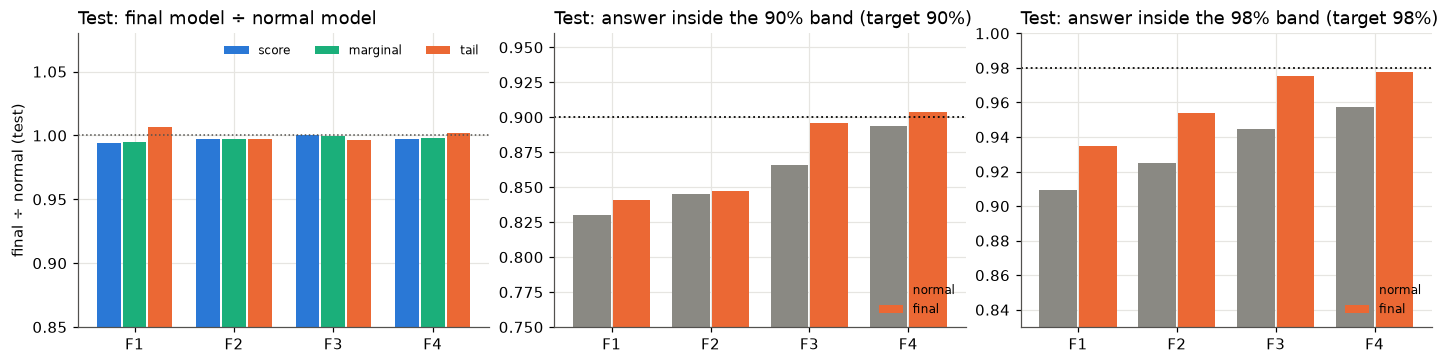

In [9]:
fams = sorted(FAM)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), layout="constrained")
x = np.arange(len(fams))
for j, (col, lab) in enumerate((("ratio", "score"), ("marginal_ratio", "marginal"), ("tail_ratio", "tail"))):
    axes[0].bar(x + (j - 1) * 0.26, [geo(te_res.loc[te_res.family == f, col]) for f in fams], width=0.24,
                color=["#2a78d6", "#1baf7a", "#eb6834"][j], label=lab)
axes[0].axhline(1, color=INK2, ls=":", lw=1); axes[0].set_xticks(x, [f[3:] for f in fams]); axes[0].set_ylim(0.85, 1.08)
axes[0].set_ylabel("final ÷ normal (test)"); axes[0].set_title("Test: final model ÷ normal model"); axes[0].legend(fontsize=8, ncols=3)
for ax, b, tgt in ((axes[1], 90, 0.9), (axes[2], 98, 0.98)):
    ax.bar(x - 0.2, [te_res.loc[te_res.family == f, f"cov{b}_normal"].mean() for f in fams], width=0.38, color=NORMAL_C, label="normal")
    ax.bar(x + 0.2, [te_res.loc[te_res.family == f, f"cov{b}_t"].mean() for f in fams], width=0.38, color=T_C, label="final")
    ax.axhline(tgt, color=INK, ls=":", lw=1.2); ax.set_xticks(x, [f[3:] for f in fams])
    ax.set_ylim(tgt - 0.15, min(1.0, tgt + 0.06)); ax.set_title(f"Test: answer inside the {b}% band (target {b}%)"); ax.legend(fontsize=8, loc="lower right")
plt.show()

**PIT on test** — normal model against the final model. Flat = calibrated; high at both ends = tails too thin.

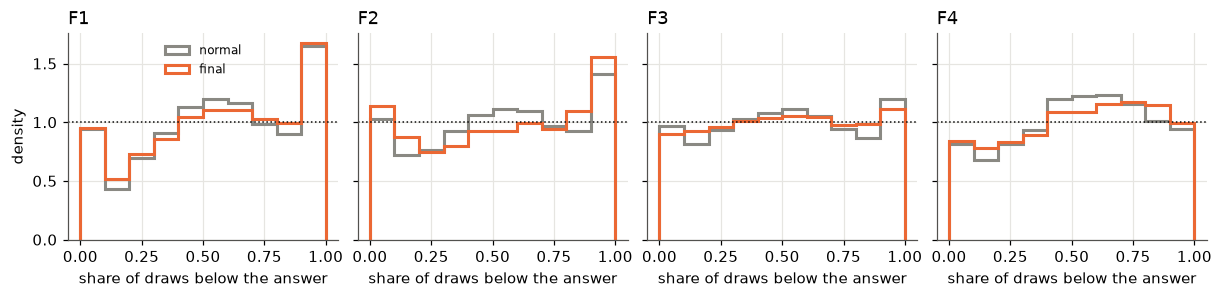

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(11, 2.6), layout="constrained", sharey=True)
bins = np.linspace(0, 1, 11)
for ax, f in zip(axes, fams):
    for model, col, lab in ((NORMAL, NORMAL_C, "normal"), (FINAL, T_C, "final")):
        mine = pd.Series([key(model[u]) for u in te_pit.unit], index=te_pit.index)
        v = te_pit.loc[(te_pit.family == f) & (te_pit.setting == mine), "pit"]
        ax.hist(v, bins=bins, density=True, histtype="step", lw=2, color=col, label=lab)
    ax.axhline(1, color=INK, lw=1, ls=":"); ax.set_title(f[3:]); ax.set_xlabel("share of draws below the answer")
axes[0].set_ylabel("density"); axes[0].legend(fontsize=8, loc="upper center"); plt.show()

## 7 — Every card on test

In [11]:
card_tab = te_res.set_index(["family", "unit"])[["score_normal", "score_t", "ratio", "tail_ratio",
                                                   "cov90_normal", "cov90_t", "cov98_normal", "cov98_t"]]
card_tab.insert(0, "final setting", [key(FINAL[u]) for u in card_tab.index.get_level_values("unit")])
card_tab.style.format({c: "{:.3f}" for c in card_tab.columns if c not in ("final setting", "score_normal", "score_t")}
                      | {"score_normal": "{:.4g}", "score_t": "{:.4g}"}).background_gradient(subset=["ratio"], cmap="RdYlGn_r", vmin=0.9, vmax=1.1)

## 8 — Save

In [12]:
pd.DataFrame({"family": FAMILY, "normal": {u: key(NORMAL[u]) for u in CARDS}, "final": {u: key(FINAL[u]) for u in CARDS}}
             ).to_csv(DATA / "t_settings.csv")
tr.to_parquet(DATA / "t_tune_train.parquet", index=False)
va.to_parquet(DATA / "t_validation.parquet", index=False)
te.to_parquet(DATA / "t_test.parquet", index=False)
te_res.to_csv(DATA / "t_test_per_unit.csv", index=False)
for f in ("t_settings.csv", "t_tune_train.parquet", "t_validation.parquet", "t_test.parquet", "t_test_per_unit.csv"):
    print(f"data/{f:<24} {(DATA / f).stat().st_size / 1e6:6.2f} MB")

data/t_settings.csv             0.01 MB
data/t_tune_train.parquet       9.78 MB
data/t_validation.parquet       1.21 MB
data/t_test.parquet             1.79 MB
data/t_test_per_unit.csv        0.02 MB
